In [1]:
# ============================================
# Setup
# ============================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.ticker import FuncFormatter

RESULT_DIR = Path("../results")
SPECIES = ["AT21", "NB21", "OS21"]

SPECIES_INFO = {
    "AT21": {"label": "AT", "color": "#664D0AFF", "marker": "o"},
    "NB21": {"label": "NB", "color": "#7e3131", "marker": "^"},
    "OS21": {"label": "OS", "color": "#13563f", "marker": "s"},
}

_PLOT_CFG = {"fig_w": 6.0, "fig_h": 6.0, "dpi": 300}

sns.set_style("ticks")
mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 10, "figure.dpi": 300,
    "savefig.dpi": 300, "axes.linewidth": 1.2, "axes.spines.top": True,
    "axes.spines.right": True, "axes.grid": False, "xtick.major.size": 6,
    "ytick.major.size": 6, "xtick.direction": "out", "ytick.direction": "out",
    "legend.frameon": False, "savefig.bbox": "tight",
})

In [2]:
# ============================================
# Plot helpers
# ============================================

def make_fig(w=None, h=None, dpi=None):
    return plt.subplots(
        figsize=(w or _PLOT_CFG["fig_w"], h or _PLOT_CFG["fig_h"]),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

def format_axis(ax, *, xlabel=None, ylabel=None):
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    return ax

In [16]:
# ============================================
# Feature annotation
# ============================================

def extract_region(feature):
    if feature.startswith("5'UTR."): return "5'UTR"
    if feature.startswith("CDS."): return "CDS"
    if feature.startswith("3'UTR."): return "3'UTR"
    return "mRNA"

def extract_feature_type(feature):
    if feature.endswith(".Length"): return "Length"
    if ".uAUG" in feature or ".uORF" in feature or ".dAUG" in feature or ".dORF" in feature: return "ORF_nonCDS"
    if feature.endswith(".MFE"): return "RNA_structure_MFE"
    if ".wobble_pct_" in feature: return "Wobble"
    if ".aa_pct_" in feature: return "Amino_acid_composition"
    if ".dicodon_" in feature: return "Dicodon"
    if re.search(r"\.[A-Z][a-z]{2}-[AUGC]{3}$", feature): return "Codon_usage"
    if feature.endswith("-freq"): return "Nucleotide_kmer_freq"
    return "Other"

In [17]:
# ============================================
# Load LightGBM feature importance
# ============================================

importance_rows = []

for species_key in SPECIES:
    path = RESULT_DIR / "lgbm" / f"{species_key}.lgbm.feature_importance.tsv"
    temp = pd.read_csv(path, sep="\t")[["feature", "importance"]].copy()
    temp["Species_key"] = species_key
    temp["Species"] = SPECIES_INFO[species_key]["label"]
    importance_rows.append(temp)

importance_long = pd.concat(importance_rows, ignore_index=True).rename(
    columns={"feature": "Feature", "importance": "Importance_raw"}
)

importance_long["Region"] = importance_long["Feature"].apply(extract_region)
importance_long["Feature_type"] = importance_long["Feature"].apply(extract_feature_type)

print("LightGBM feature importance:", importance_long.shape)
display(importance_long.head())

# ============================================
# Normalize feature importance within species
# ============================================

importance_matrix = (
    importance_long
    .pivot(index="Feature", columns="Species_key", values="Importance_raw")
    .reindex(columns=SPECIES)
    .fillna(0)
)

importance_norm = importance_matrix.div(importance_matrix.sum(axis=0), axis=1)

print("Importance matrix:", importance_matrix.shape)
print("Normalized sums")
display(importance_norm.sum(axis=0))

LightGBM feature importance: (1304, 6)


,Feature,Importance_raw,Species_key,Species,Region,Feature_type
0,5'UTR.CUU-freq,29.0,AT21,AT,5'UTR,Nucleotide_kmer_freq
1,5'UTR.C-freq,28.0,AT21,AT,5'UTR,Nucleotide_kmer_freq
2,5'UTR.S-freq,27.0,AT21,AT,5'UTR,Nucleotide_kmer_freq
3,5'UTR.U-freq,26.0,AT21,AT,5'UTR,Nucleotide_kmer_freq
4,5'UTR.MFE,25.0,AT21,AT,5'UTR,RNA_structure_MFE


Importance matrix: (449, 3)
Normalized sums


Species_key
AT21    1.0
NB21    1.0
OS21    1.0
dtype: float64

In [18]:
# ============================================
# Species Specificity Score (SSS)
# ============================================

AT, NB, OS = importance_norm["AT21"], importance_norm["NB21"], importance_norm["OS21"]

sss_df = pd.DataFrame({
    "AT_SSS": np.sqrt((AT - NB) ** 2 + (AT - OS) ** 2),
    "NB_SSS": np.sqrt((NB - AT) ** 2 + (NB - OS) ** 2),
    "OS_SSS": np.sqrt((OS - AT) ** 2 + (OS - NB) ** 2),
    "AT_Delta": AT - (NB + OS) / 2,
    "NB_Delta": NB - (AT + OS) / 2,
    "OS_Delta": OS - (AT + NB) / 2,
}).reset_index()

sss_df["Region"] = sss_df["Feature"].apply(extract_region)
sss_df["Feature_type"] = sss_df["Feature"].apply(extract_feature_type)

print("SSS table:", sss_df.shape)
display(sss_df.head())

# ============================================
# Long-format SSS + normalized importance
# ============================================

sss_long = pd.concat([
    sss_df[["Feature", "Region", "Feature_type", f"{sp}_SSS", f"{sp}_Delta"]]
    .rename(columns={f"{sp}_SSS": "SSS", f"{sp}_Delta": "Delta"})
    .assign(Species=sp)
    for sp in ["AT", "NB", "OS"]
], ignore_index=True)

importance_norm_long = (
    importance_norm.reset_index()
    .melt(id_vars="Feature", var_name="Species_key", value_name="Importance_normalized")
)

importance_norm_long["Species"] = importance_norm_long["Species_key"].map({
    "AT21": "AT", "NB21": "NB", "OS21": "OS"
})

candidate_df = (
    sss_long
    .merge(
        importance_norm_long[["Feature", "Species", "Importance_normalized"]],
        on=["Feature", "Species"], how="left", validate="one_to_one"
    )
)

print("Candidate table:", candidate_df.shape)
display(candidate_df.head())

SSS table: (449, 9)


,Feature,AT_SSS,NB_SSS,OS_SSS,AT_Delta,NB_Delta,OS_Delta,Region,Feature_type
0,3'UTR.A-freq,0.002228,0.002049,0.003016,-0.001200,-0.000931,0.002131,3'UTR,Nucleotide_kmer_freq
1,3'UTR.AA-freq,0.002280,0.003303,0.002395,0.001081,-0.002335,0.001254,3'UTR,Nucleotide_kmer_freq
2,3'UTR.AAA-freq,0.002856,0.002504,0.001772,-0.001981,0.001584,0.000397,3'UTR,Nucleotide_kmer_freq
3,3'UTR.AAC-freq,0.002329,0.002022,0.001447,0.001617,-0.001271,-0.000347,3'UTR,Nucleotide_kmer_freq
4,3'UTR.AAG-freq,0.001495,0.001762,0.002278,0.000599,0.001006,-0.001605,3'UTR,Nucleotide_kmer_freq


Candidate table: (1347, 7)


,Feature,Region,Feature_type,SSS,Delta,Species,Importance_normalized
0,3'UTR.A-freq,3'UTR,Nucleotide_kmer_freq,0.002228,-0.001200,AT,0.001579
1,3'UTR.AA-freq,3'UTR,Nucleotide_kmer_freq,0.002280,0.001081,AT,0.003684
2,3'UTR.AAA-freq,3'UTR,Nucleotide_kmer_freq,0.002856,-0.001981,AT,0.000789
3,3'UTR.AAC-freq,3'UTR,Nucleotide_kmer_freq,0.002329,0.001617,AT,0.003684
4,3'UTR.AAG-freq,3'UTR,Nucleotide_kmer_freq,0.001495,0.000599,AT,0.002895


/tmp/ipykernel_1601777/2640100956.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1601777/2640100956.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_1601777/2640100956.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1601777/2640100956.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_1601777/2640100956.

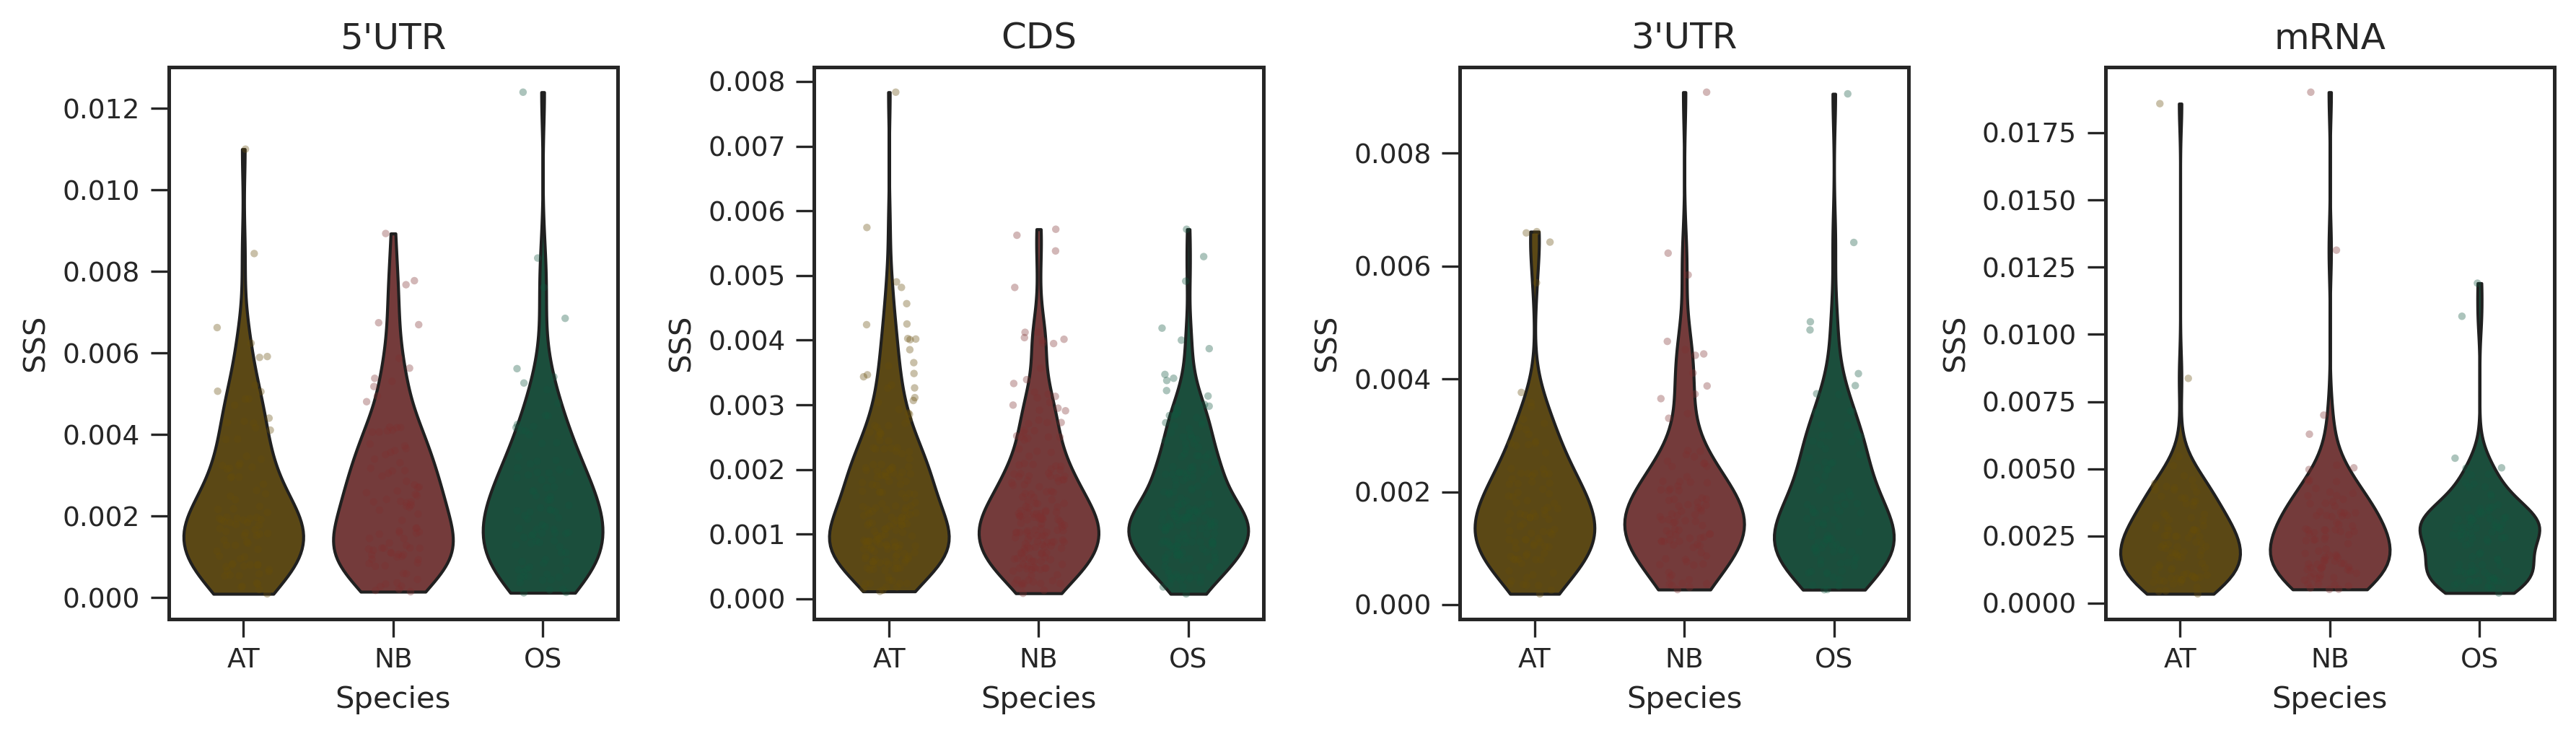

In [23]:
# ============================================
# SSS distribution by transcript region
# Violin + stripplot
# ============================================

region_order = ["5'UTR", "CDS", "3'UTR", "mRNA"]
species_order = ["AT", "NB", "OS"]
palette = {SPECIES_INFO[k]["label"]: SPECIES_INFO[k]["color"] for k in SPECIES}

fig, axes = plt.subplots(1, 4, figsize=(12, 3.5), dpi=_PLOT_CFG["dpi"])

for ax, region in zip(axes, region_order):
    temp = sss_long.loc[sss_long["Region"] == region]

    sns.violinplot(
        data=temp, x="Species", y="SSS", order=species_order,
        palette=palette, inner=None, cut=0, linewidth=1, ax=ax,
    )

    sns.stripplot(
        data=temp, x="Species", y="SSS", order=species_order,
        palette=palette, size=2.5, alpha=0.35,
        jitter=0.18, linewidth=0, ax=ax,
    )

    ax.set_title(region)
    format_axis(ax, xlabel=None, ylabel="SSS" if ax is axes[0] else None)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1601777/1145124592.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1601777/1145124592.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_1601777/1145124592.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1601777/1145124592.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_1601777/1145124592.

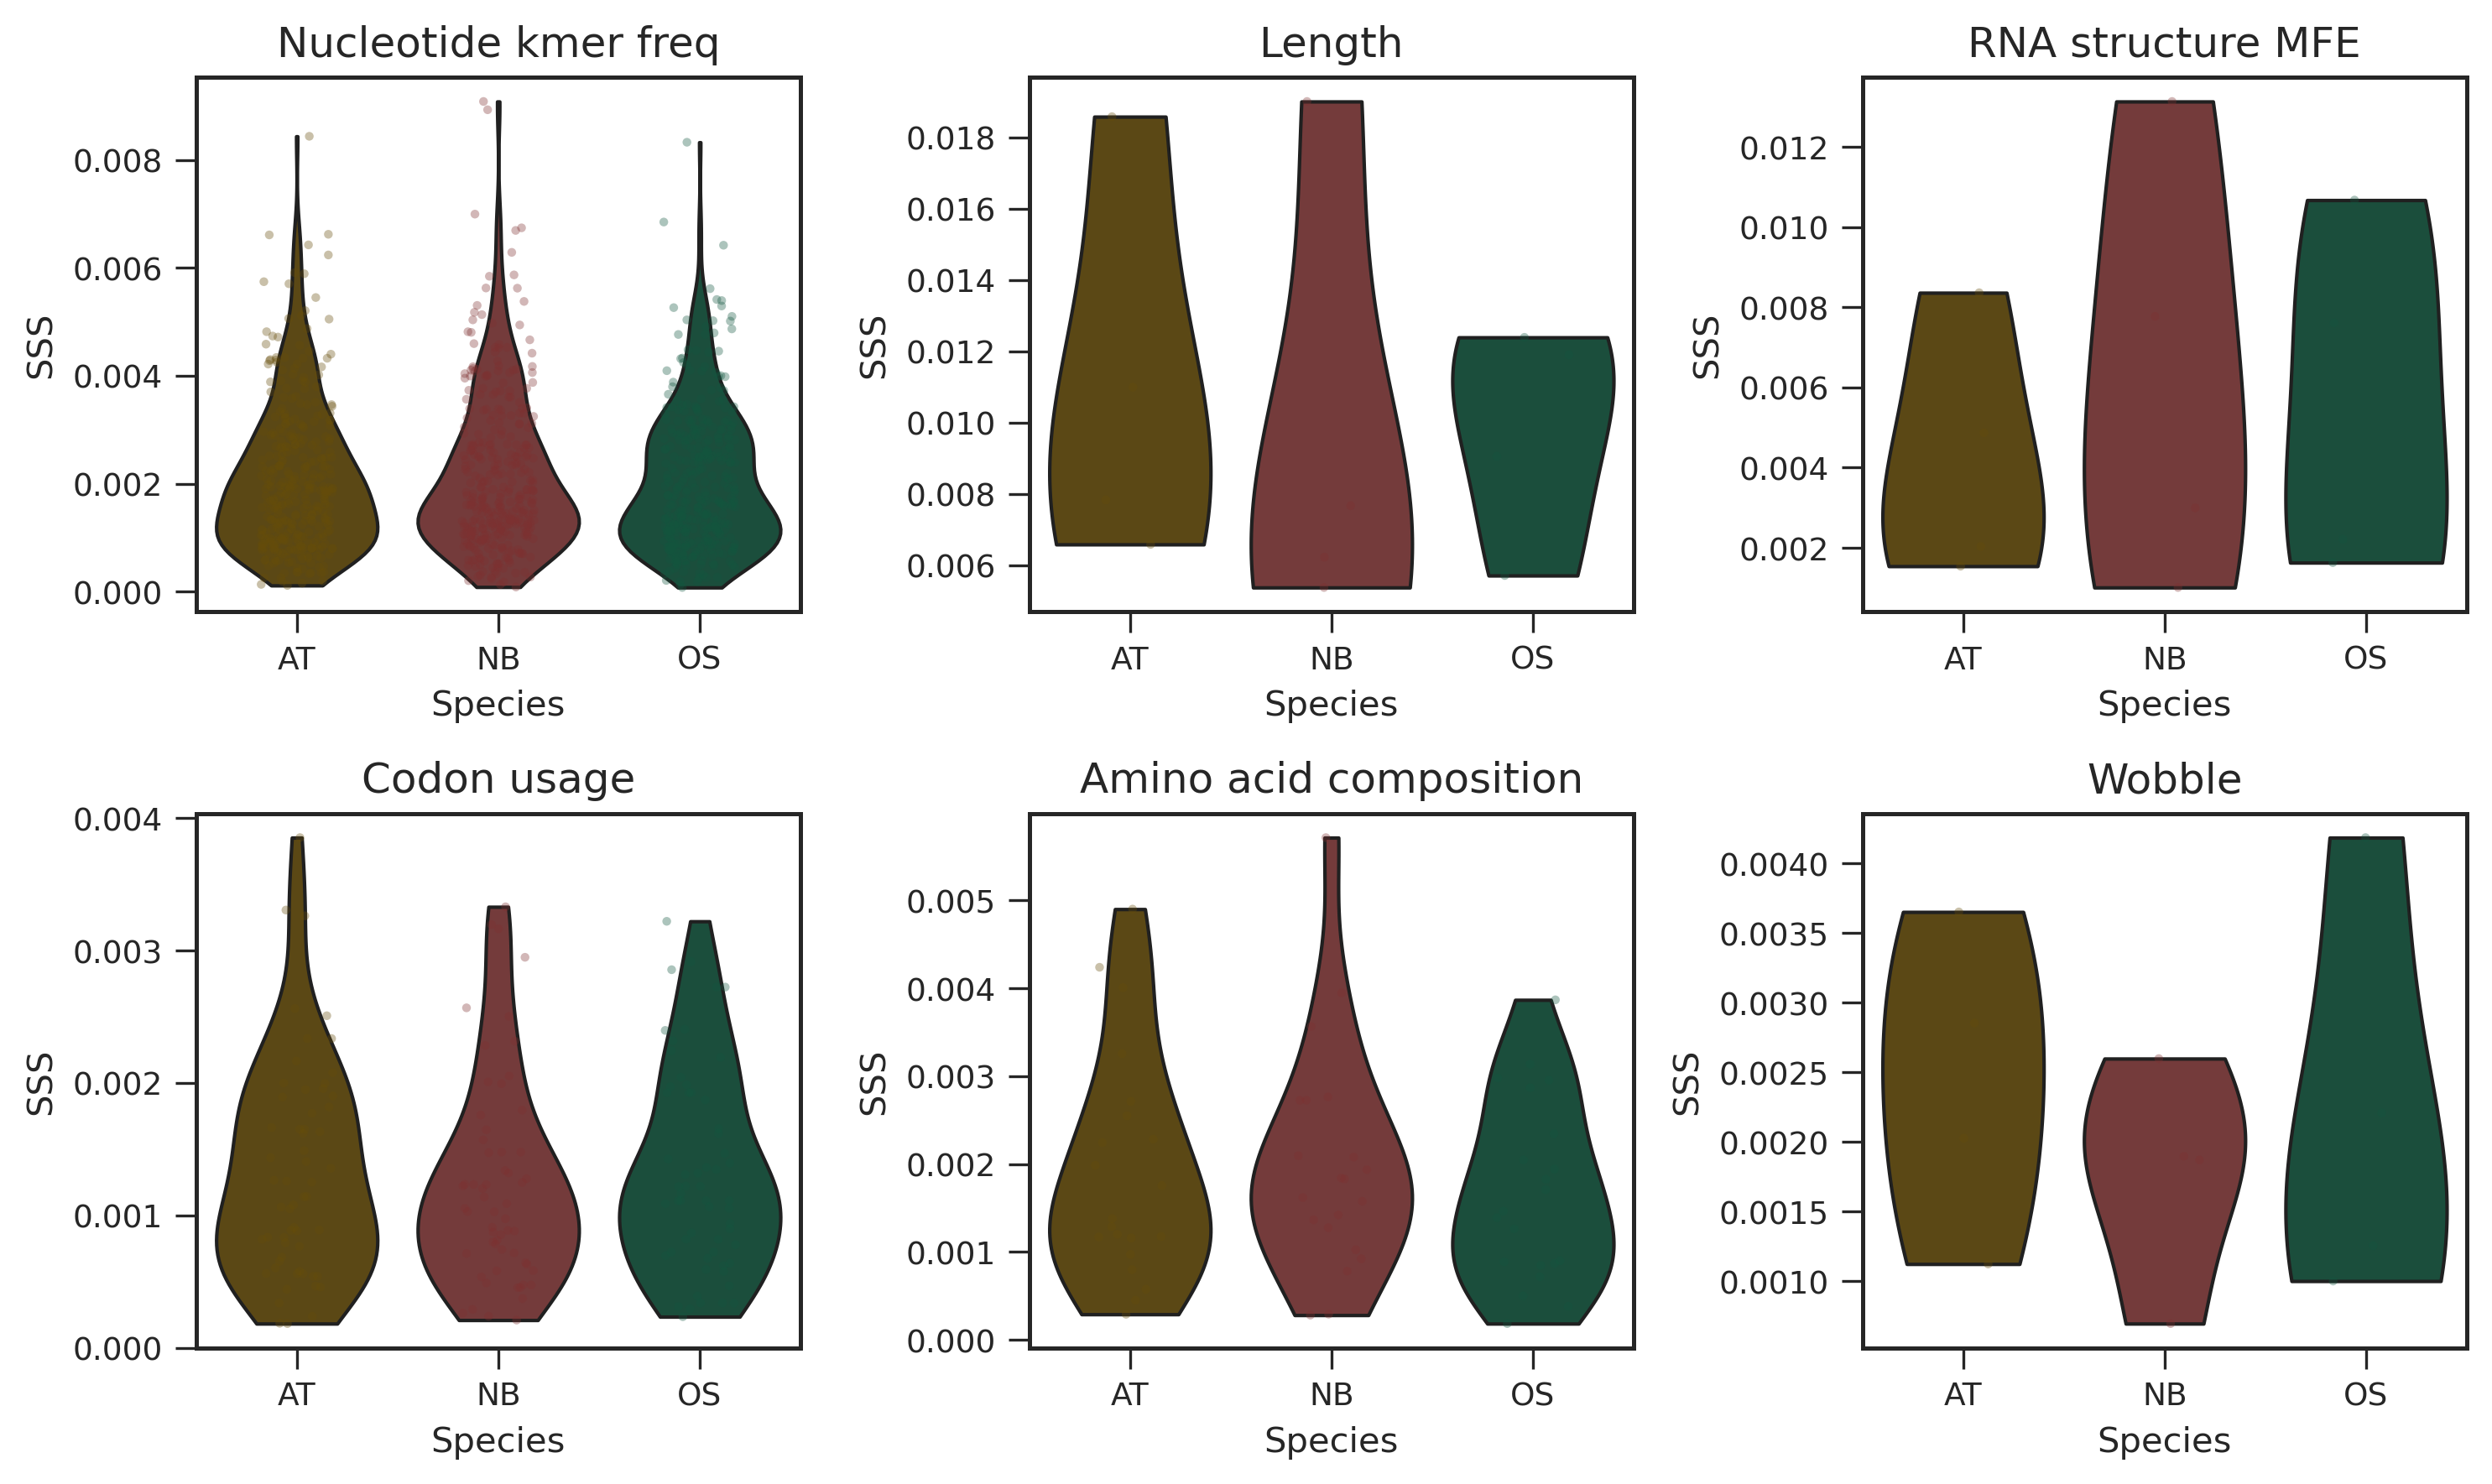

In [24]:
# ============================================
# SSS distribution by feature category
# Violin + stripplot
# ============================================

feature_order = [
    "Nucleotide_kmer_freq", "Length", "RNA_structure_MFE",
    "Codon_usage", "Amino_acid_composition", "Wobble",
]

species_order = ["AT", "NB", "OS"]
palette = {SPECIES_INFO[k]["label"]: SPECIES_INFO[k]["color"] for k in SPECIES}

fig, axes = plt.subplots(2, 3, figsize=(10, 6), dpi=_PLOT_CFG["dpi"])

for ax, feature_type in zip(axes.flat, feature_order):
    temp = sss_long.loc[sss_long["Feature_type"] == feature_type]

    sns.violinplot(
        data=temp, x="Species", y="SSS", order=species_order,
        palette=palette, inner=None, cut=0, linewidth=1, ax=ax,
    )

    sns.stripplot(
        data=temp, x="Species", y="SSS", order=species_order,
        palette=palette, size=2.5, alpha=0.35,
        jitter=0.18, linewidth=0, ax=ax,
    )

    ax.set_title(feature_type.replace("_", " "))
    format_axis(ax, xlabel=None, ylabel="SSS" if ax in axes[:, 0] else None)

plt.tight_layout()
plt.show()

In [8]:
# ============================================
# Species-wise percentile ranking
# ============================================

candidate_df["Importance_percentile"] = (
    candidate_df.groupby("Species")["Importance_normalized"].rank(pct=True)
)

candidate_df["SSS_percentile"] = (
    candidate_df.groupby("Species")["SSS"].rank(pct=True)
)

candidate_df["Enrichment"] = np.where(candidate_df["Delta"] > 0, "Enriched", "Depleted")

display(
    candidate_df[
        ["Species", "Feature", "Region", "Feature_type",
         "Importance_normalized", "Importance_percentile",
         "SSS", "SSS_percentile", "Delta", "Enrichment"]
    ].head()
)

,Species,Feature,Region,Feature_type,Importance_normalized,Importance_percentile,SSS,SSS_percentile,Delta,Enrichment
0,AT,3'UTR.A-freq,3'UTR,Other,0.001579,0.359688,0.002228,0.659243,-0.001200,Depleted
1,AT,3'UTR.AA-freq,3'UTR,Other,0.003684,0.863029,0.002280,0.672606,0.001081,Enriched
2,AT,3'UTR.AAA-freq,3'UTR,Other,0.000789,0.138085,0.002856,0.781737,-0.001981,Depleted
3,AT,3'UTR.AAC-freq,3'UTR,Other,0.003684,0.863029,0.002329,0.689310,0.001617,Enriched
4,AT,3'UTR.AAG-freq,3'UTR,Other,0.002895,0.743875,0.001495,0.440980,0.000599,Enriched


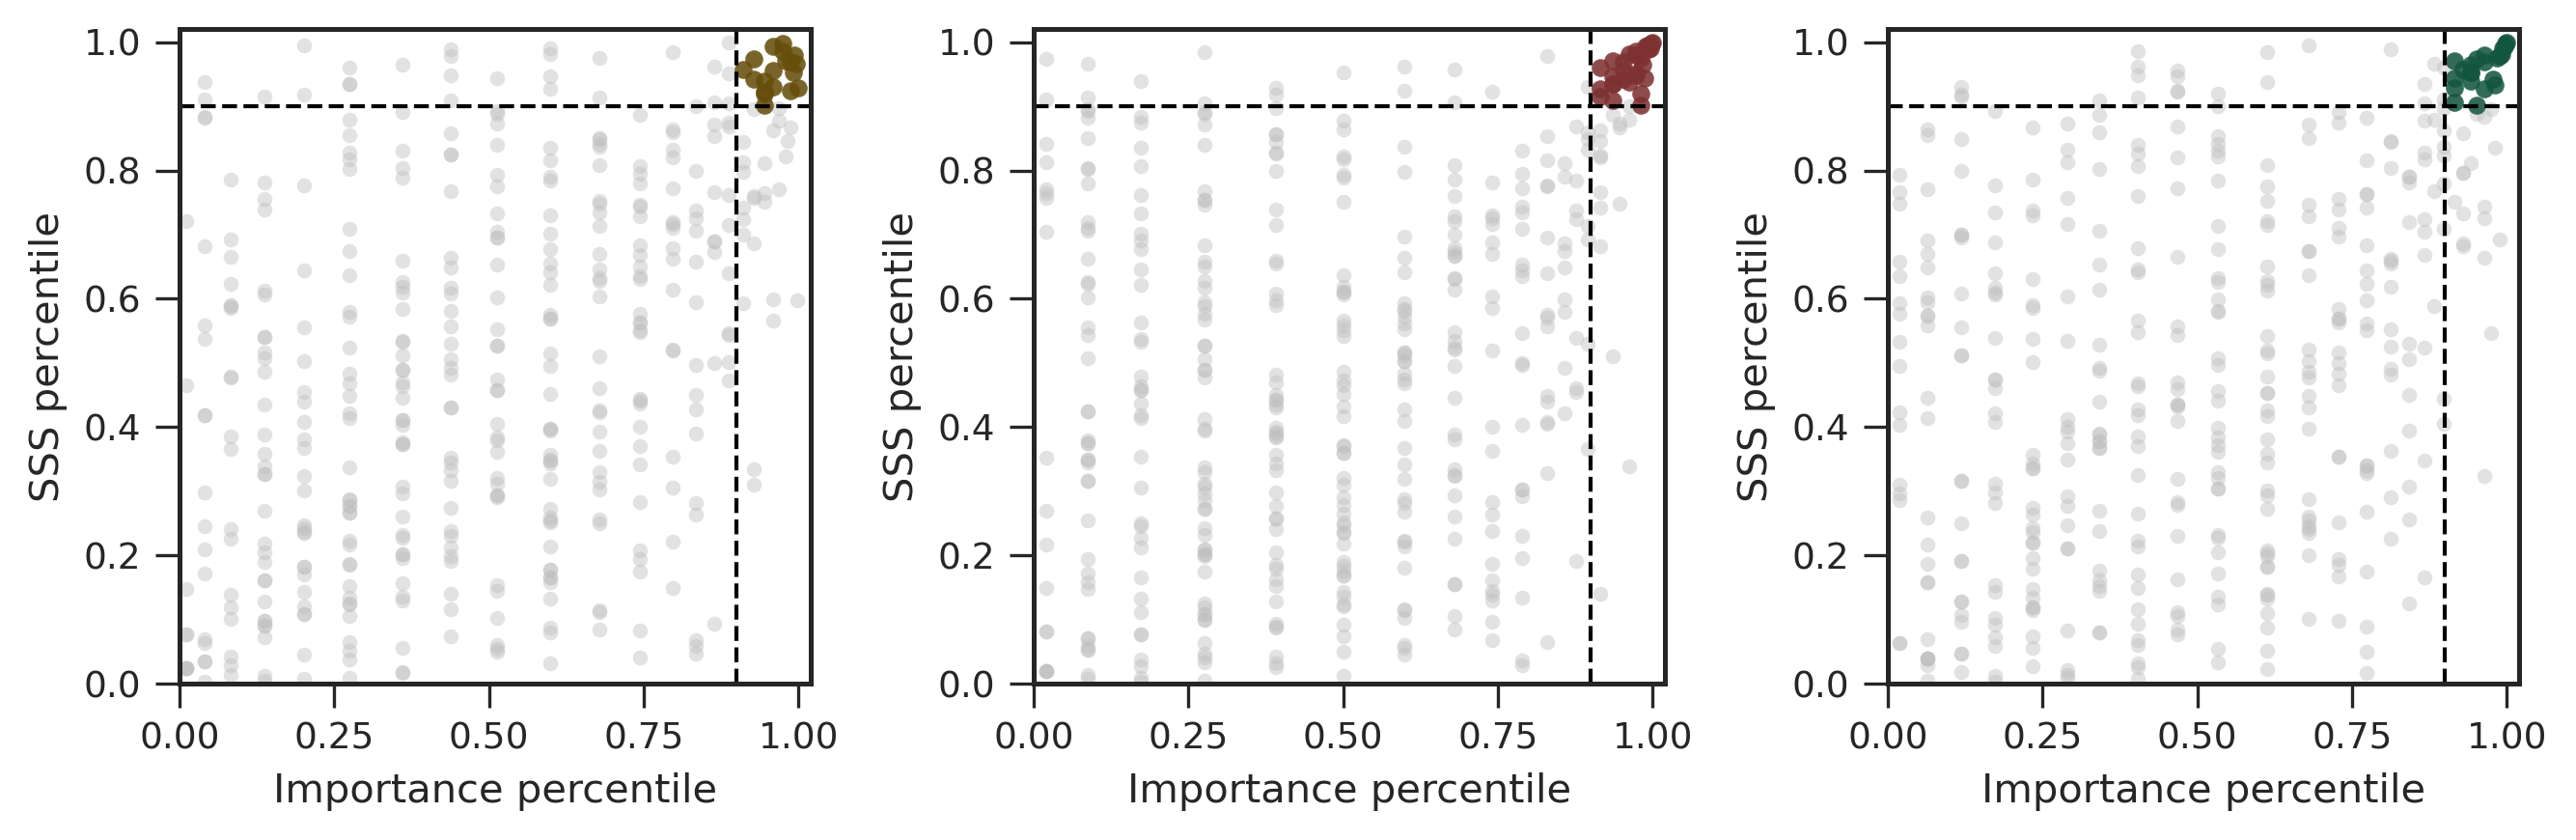

In [11]:
# ============================================
# Joint percentile space
# Importance × SSS
# ============================================

CUTOFF = 0.90

fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    color = SPECIES_INFO[species_key]["color"]
    temp = candidate_df.loc[candidate_df["Species"] == species].copy()
    keep = (temp["Importance_percentile"] >= CUTOFF) & (temp["SSS_percentile"] >= CUTOFF)

    ax.scatter(temp["Importance_percentile"], temp["SSS_percentile"],
               s=14, color="0.75", alpha=0.45, linewidth=0)

    ax.scatter(temp.loc[keep, "Importance_percentile"], temp.loc[keep, "SSS_percentile"],
               s=20, color=color, alpha=0.85, linewidth=0)

    ax.axvline(CUTOFF, color="black", ls="--", lw=1)
    ax.axhline(CUTOFF, color="black", ls="--", lw=1)

    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    format_axis(ax, xlabel="Importance percentile", ylabel="SSS percentile")

plt.tight_layout()
plt.show()

In [12]:
# ============================================
# Matched threshold path
# Importance cutoff = SSS cutoff
# ============================================

cutoffs = np.arange(0.00, 1.00, 0.05)
threshold_sets, rows = {}, []

for species in ["AT", "NB", "OS"]:
    for cutoff in cutoffs:
        features = set(candidate_df.loc[
            (candidate_df["Species"] == species) &
            (candidate_df["Importance_percentile"] >= cutoff) &
            (candidate_df["SSS_percentile"] >= cutoff),
            "Feature"
        ])

        threshold_sets[(species, cutoff)] = features
        rows.append({"Species": species, "Cutoff": cutoff, "N_features": len(features)})

threshold_path_df = pd.DataFrame(rows)

print("Matched threshold path")
display(threshold_path_df)

Matched threshold path


,Species,Cutoff,N_features
0,AT,0.00,449
1,AT,0.05,407
2,AT,0.10,373
3,AT,0.15,331
4,AT,0.20,313
5,AT,0.25,283
6,AT,0.30,243
7,AT,0.35,226
8,AT,0.40,189
9,AT,0.45,160


In [13]:
# ============================================
# Export matched threshold feature sets
# ============================================

threshold_feature_df = pd.DataFrame([
    {"Species": species, "Cutoff": cutoff, "Feature": feature}
    for (species, cutoff), features in threshold_sets.items()
    for feature in sorted(features)
])

threshold_feature_df = threshold_feature_df.sort_values(
    ["Species", "Cutoff", "Feature"]
).reset_index(drop=True)

outfile = RESULT_DIR / "lgbm" / "lgbm.retention_feature_sets.tsv.gz"
threshold_feature_df.to_csv(outfile, sep="\t", index=False, compression="gzip")

print(f"Saved: {outfile}")
display(
    threshold_feature_df.groupby(["Species", "Cutoff"])
    .size().rename("N_features").reset_index()
)

Saved: ../results/lgbm/lgbm.retention_feature_sets.tsv.gz


,Species,Cutoff,N_features
0,AT,0.00,449
1,AT,0.05,407
2,AT,0.10,373
3,AT,0.15,331
4,AT,0.20,313
5,AT,0.25,283
6,AT,0.30,243
7,AT,0.35,226
8,AT,0.40,189
9,AT,0.45,160
